In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os

dataset_path = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/kaggle/input/datasets/elmadafri/the-wildfire-dataset
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/fire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/nofire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/fire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/nofire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/fire


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths

train_path = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train"

val_path = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val"

test_path = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

2026-06-05 10:00:10.340725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780653610.510086      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780653610.562051      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780653610.984240      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780653610.984270      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780653610.984273      58 computation_placer.cc:177] computation placer alr

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.


In [11]:
print("Classes:", train_data.class_indices)
print("Training Images:", train_data.samples)
print("Validation Images:", val_data.samples)
print("Testing Images:", test_data.samples)

Classes: {'fire': 0, 'nofire': 1}
Training Images: 1887
Validation Images: 402
Testing Images: 410


In [12]:
ImageDataGenerator(
    rescale=1./255
)

In [14]:
IMG_SIZE = (224,224)

In [16]:
rescale=1./255

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [21]:
model = Sequential([

    Conv2D(32,(3,3),
           activation='relu',
           input_shape=(224,224,3)),

    MaxPooling2D(2,2),

    Conv2D(64,(3,3),
           activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128,(3,3),
           activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,
          activation='relu'),

    Dropout(0.5),

    Dense(1,
          activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780654337.561514      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780654337.567565      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15


I0000 00:00:1780654440.784936     180 service.cc:152] XLA service 0x7c5754004700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780654440.784973     180 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780654440.784977     180 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780654441.225602     180 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 10:14:03.733875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 10:14:03.882674: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/59 ━━━━━━━━━━━━━━━━━━━━ 13:59 14s/step - accuracy: 0.5000 - loss: 0.6909

I0000 00:00:1780654446.576941     180 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 8/59 ━━━━━━━━━━━━━━━━━━━━ 4:57 6s/step - accuracy: 0.5652 - loss: 0.7854

...

15/59 ━━━━━━━━━━━━━━━━━━━━ 4:48 7s/step - accuracy: 0.5757 - loss: 0.7606

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


30/59 ━━━━━━━━━━━━━━━━━━━━ 3:24 7s/step - accuracy: 0.5942 - loss: 0.7197

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


59/59 ━━━━━━━━━━━━━━━━━━━━ 507s 8s/step - accuracy: 0.6587 - loss: 0.6058 - val_accuracy: 0.7313 - val_loss: 0.5088
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 429s 7s/step - accuracy: 0.7345 - loss: 0.5149 - val_accuracy: 0.7114 - val_loss: 0.5199
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 455s 8s/step - accuracy: 0.7260 - loss: 0.5157 - val_accuracy: 0.7239 - val_loss: 0.5272
Epoch 4/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 432s 7s/step - accuracy: 0.7658 - loss: 0.4828 - val_accuracy: 0.7463 - val_loss: 0.4855
Epoch 5/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 436s 7s/step - accuracy: 0.7912 - loss: 0.4591 - val_accuracy: 0.7637 - val_loss: 0.4721
Epoch 6/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 469s 8s/step - accuracy: 0.7917 - loss: 0.4481 - val_accuracy: 0.7662 - val_loss: 0.4699
Epoch 7/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 470s 8s/step - accuracy: 0.7732 - loss: 0.4618 - val_accuracy: 0.7512 - val_loss: 0.5151
Epoch 8/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 491s 8s/step - accuracy: 0.7891 - loss: 0.4593 - val_accuracy: 0.7438 - val_loss: 0.

In [27]:
import matplotlib.pyplot as plt

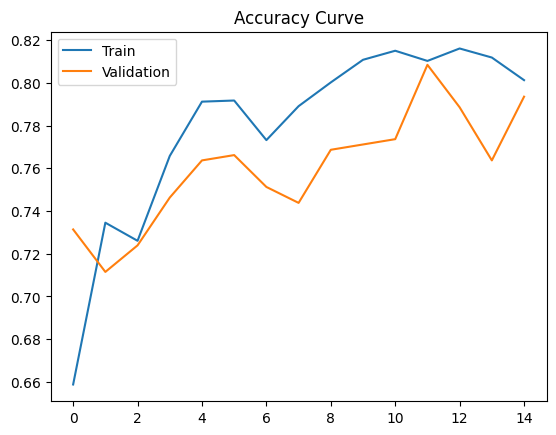

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])

plt.title("Accuracy Curve")
plt.savefig("accuracy_curve.png")
plt.show()


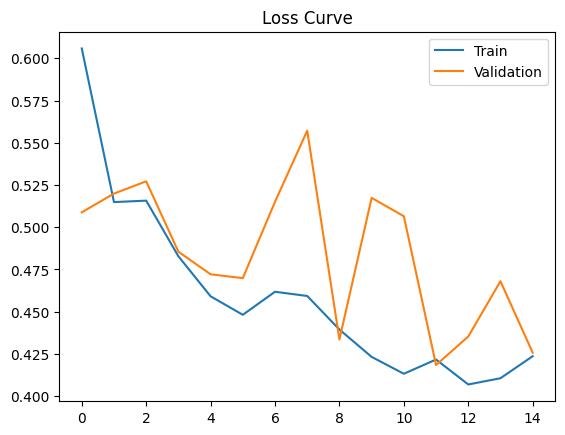

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(
['Train','Validation']
)

plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

In [30]:
pred = model.predict(test_data)

y_pred = (pred > 0.5).astype(int)

 5/13 ━━━━━━━━━━━━━━━━━━━━ 2:41 20s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 2:51 25s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 303s 25s/step


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_data.classes,
    y_pred
)

In [32]:
from sklearn.metrics import classification_report

print(
classification_report(
    test_data.classes,
    y_pred
)
)

              precision    recall  f1-score   support

           0       0.81      0.70      0.75       159
           1       0.83      0.90      0.86       251

    accuracy                           0.82       410
   macro avg       0.82      0.80      0.81       410
weighted avg       0.82      0.82      0.82       410



In [34]:
from tensorflow.keras.applications import MobileNetV2

In [35]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
base_model.trainable=False

In [37]:
plt.savefig("accuracy_curve.png")

plt.savefig("loss_curve.png")

plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [38]:
cnn_loss, cnn_acc = model.evaluate(test_data)

print("CNN Accuracy:", cnn_acc)

 5/13 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.7324 - loss: 0.5562

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.7301 - loss: 0.5604

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 103s 8s/step - accuracy: 0.8220 - loss: 0.3941
CNN Accuracy: 0.8219512104988098


In [40]:
model.evaluate(test_data)

13/13 ━━━━━━━━━━━━━━━━━━━━ 86s 7s/step - accuracy: 0.8220 - loss: 0.3941


[0.3941233456134796, 0.8219512104988098]

In [43]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense

In [45]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [47]:
inputs = Input(shape=(224,224,3))

x = base_model(inputs)

x = GlobalAveragePooling2D()(x)

outputs = Dense(
    1,
    activation='sigmoid'
)(x)

mobilenet_model = Model(inputs, outputs)

In [48]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Accuracy:", mobilenet_acc)

12/13 ━━━━━━━━━━━━━━━━━━━━ 7s 8s/step - accuracy: 0.7748 - loss: 0.5095 

2026-06-05 13:17:37.800318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 13:17:37.939502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 13:17:38.076018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


13/13 ━━━━━━━━━━━━━━━━━━━━ 106s 8s/step - accuracy: 0.8585 - loss: 0.3421
MobileNetV2 Accuracy: 0.8585366010665894


13/13 ━━━━━━━━━━━━━━━━━━━━ 103s 8s/step


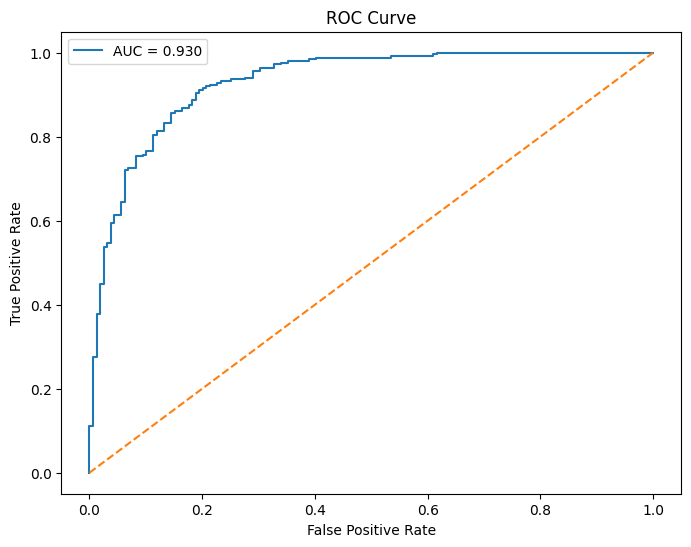

In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = test_data.classes

y_scores = mobilenet_model.predict(test_data).ravel()

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

plt.savefig('roc_curve.png')
plt.show()

In [53]:
import numpy as np
import matplotlib.pyplot as plt

pred_probs = mobilenet_model.predict(test_data)

pred_labels = (pred_probs > 0.5).astype(int).flatten()

true_labels = test_data.classes

misclassified = np.where(pred_labels != true_labels)[0]

print("Number of Misclassified Images:",
      len(misclassified))

 5/13 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 7s/step
Number of Misclassified Images: 58


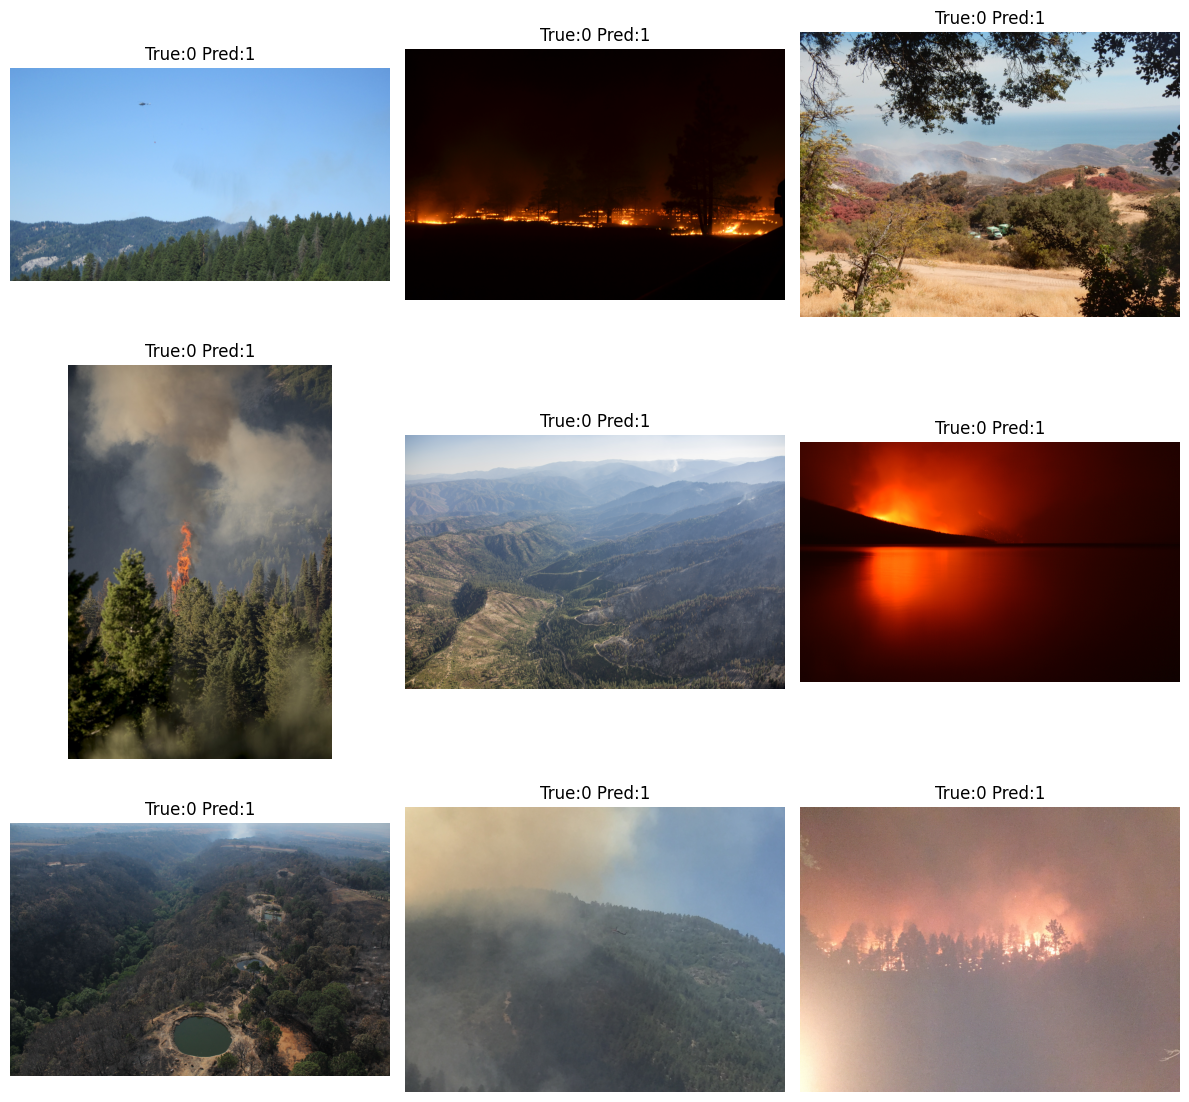

In [54]:
plt.figure(figsize=(12,12))

for i, idx in enumerate(misclassified[:9]):

    img = plt.imread(test_data.filepaths[idx])

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"True:{true_labels[idx]} Pred:{pred_labels[idx]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig("error_analysis.png")

plt.show()

In [55]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [57]:
img_path = test_data.filepaths[0]

In [59]:
img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [66]:
last_conv_layer_name = "Conv_1"

In [68]:
for layer in base_model.layers[-20:]:
    print(layer.name)

block_15_expand
block_15_expand_BN
block_15_expand_relu
block_15_depthwise
block_15_depthwise_BN
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


In [71]:
last_conv_layer = base_model.get_layer("Conv_1")

grad_model = tf.keras.models.Model(
    inputs=mobilenet_model.input,
    outputs=[
        last_conv_layer.output,
        mobilenet_model.output
    ]
)

In [72]:
print(base_model.summary())

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [73]:
for layer in base_model.layers[-20:]:
    print(layer.name)

block_15_expand
block_15_expand_BN
block_15_expand_relu
block_15_depthwise
block_15_depthwise_BN
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu


In [75]:
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer("Conv_1").output,
        base_model.output
    ]
)

In [77]:
img_path = test_data.filepaths[0]

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

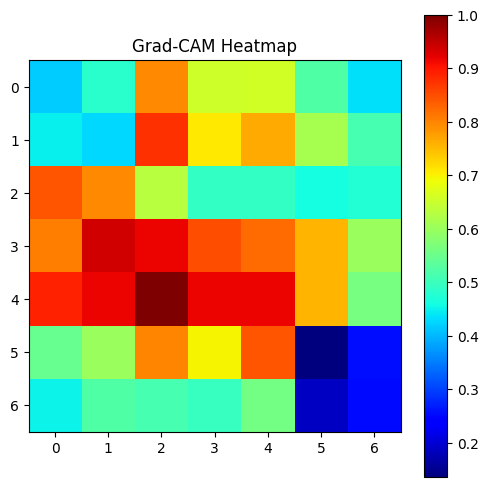

In [78]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = tf.reduce_mean(predictions)

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    pooled_grads * conv_outputs,
    axis=-1
)

heatmap = np.maximum(heatmap, 0)

heatmap = heatmap / np.max(heatmap)

plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.savefig("gradcam_heatmap.png")
plt.show()

In [79]:
import os

train_fire = len(os.listdir(train_path + "/fire"))
train_nofire = len(os.listdir(train_path + "/nofire"))

val_fire = len(os.listdir(val_path + "/fire"))
val_nofire = len(os.listdir(val_path + "/nofire"))

test_fire = len(os.listdir(test_path + "/fire"))
test_nofire = len(os.listdir(test_path + "/nofire"))

total_images = (
    train_fire + train_nofire +
    val_fire + val_nofire +
    test_fire + test_nofire
)

print("Total Images:", total_images)

print("Fire:", train_fire + val_fire + test_fire)

print("No Fire:", train_nofire + val_nofire + test_nofire)

Total Images: 2700
Fire: 1046
No Fire: 1654
